<a href="https://colab.research.google.com/github/mariasurjus1005/projeto-reprodutivel-eeg_aula1/blob/main/EEGMAT_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Análise Exploratória do Dataset EEGMAT

## EEG During Mental Arithmetic Tasks

**Objetivo:** realizar uma análise exploratória do dataset EEGMAT,
avaliando sua estrutura, características dos participantes,
distribuição dos dados e sinais de EEG registrados durante
repouso e tarefa de aritmética mental.

In [1]:
!pip install mne

In [2]:
import mne
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("MNE:", mne.__version__)
print("Tudo funcionando!")

MNE: 1.12.1
Tudo funcionando!


In [3]:
import os

os.makedirs("/content/EEGMAT", exist_ok=True)

print("Pasta criada!")

Pasta criada!


In [4]:
!wget -r -N -c -np https://physionet.org/files/eegmat/1.0.0/

--2026-09-06 14:45:43--  https://physionet.org/files/eegmat/1.0.0/
Resolving physionet.org (physionet.org)... 18.25.8.254
Connecting to physionet.org (physionet.org)|18.25.8.254|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘physionet.org/files/eegmat/1.0.0/index.html’

physionet.org/files     [ <=>                ]   9.11K  --.-KB/s    in 0s      

Last-modified header missing -- time-stamps turned off.
2026-09-06 14:45:43 (1.69 GB/s) - ‘physionet.org/files/eegmat/1.0.0/index.html’ saved [9326]

Loading robots.txt; please ignore errors.
--2026-09-06 14:45:43--  https://physionet.org/robots.txt
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK

    The file is already fully retrieved; nothing to do.

--2026-09-06 14:45:43--  https://physionet.org/files/eegmat/1.0.0/README.txt
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 304 Not Modif

In [6]:
import os

base_path = "/content/physionet.org/files/eegmat/1.0.0"

print("Conteúdo do dataset:")
print(os.listdir(base_path))

Conteúdo do dataset:
['RECORDS', 'Subject09_1.edf', 'Subject07_1.edf', 'Subject06_2.edf', 'Subject16_2.edf', 'Subject02_1.edf', 'Subject04_2.edf', 'subject-info.csv', 'Subject06_1.edf', 'Subject29_2.edf', 'Subject22_1.edf', 'Subject14_1.edf', 'Subject17_1.edf', 'Subject22_2.edf', 'Subject14_2.edf', 'Subject01_2.edf', 'Subject23_1.edf', 'Subject19_2.edf', 'Subject31_2.edf', 'Subject13_2.edf', 'Subject21_1.edf', 'Subject00_2.edf', 'Subject01_1.edf', 'Subject29_1.edf', 'Subject26_2.edf', 'Subject30_2.edf', 'Subject11_2.edf', 'Subject30_1.edf', 'Subject32_2.edf', 'Subject07_2.edf', 'Subject05_2.edf', 'Subject13_1.edf', 'Subject18_1.edf', 'Subject02_2.edf', 'Subject20_1.edf', 'Subject03_1.edf', 'Subject15_1.edf', 'Subject11_1.edf', 'Subject17_2.edf', 'Subject15_2.edf', 'Subject09_2.edf', 'Subject24_1.edf', 'Subject33_1.edf', 'Subject28_2.edf', 'Subject24_2.edf', 'Subject27_2.edf', 'Subject27_1.edf', 'Subject26_1.edf', 'Subject33_2.edf', 'Subject16_1.edf', 'Subject08_2.edf', 'Subject25_2.edf

In [7]:
import os
import glob
import pandas as pd

# Caminho do dataset baixado diretamente do PhysioNet
DATA_DIR = "/content/physionet.org/files/eegmat/1.0.0"

print("Pasta do dataset:")
print(DATA_DIR)

# Localizar arquivos EDF
edf_files = glob.glob(os.path.join(DATA_DIR, "*.edf"))

print("Quantidade de arquivos EDF:", len(edf_files))

for arquivo in sorted(edf_files)[:10]:
    print(os.path.basename(arquivo))

# Carregar informações dos participantes
csv_path = os.path.join(DATA_DIR, "subject-info.csv")

info = pd.read_csv(csv_path)

print("\nNúmero de participantes:", len(info))

print("\nVariáveis disponíveis:")
print(info.columns.tolist())

info.head()

Pasta do dataset:
/content/physionet.org/files/eegmat/1.0.0
Quantidade de arquivos EDF: 72
Subject00_1.edf
Subject00_2.edf
Subject01_1.edf
Subject01_2.edf
Subject02_1.edf
Subject02_2.edf
Subject03_1.edf
Subject03_2.edf
Subject04_1.edf
Subject04_2.edf

Número de participantes: 36

Variáveis disponíveis:
['Subject', 'Age', 'Gender', 'Recording year', 'Number of subtractions', 'Count quality']


,Subject,Age,Gender,Recording year,Number of subtractions,Count quality
0,Subject00,21,F,2011,9.70,0
1,Subject01,18,F,2011,29.35,1
2,Subject02,19,F,2012,12.88,1
3,Subject03,17,F,2010,31.00,1
4,Subject04,17,F,2010,8.60,0


In [8]:
info

,Subject,Age,Gender,Recording year,Number of subtractions,Count quality
0,Subject00,21,F,2011,9.70,0
1,Subject01,18,F,2011,29.35,1
2,Subject02,19,F,2012,12.88,1
3,Subject03,17,F,2010,31.00,1
4,Subject04,17,F,2010,8.60,0
5,Subject05,16,F,2010,20.71,1
6,Subject06,18,M,2011,4.35,0
7,Subject07,18,F,2012,13.38,1
8,Subject08,26,M,2011,18.24,1
9,Subject09,16,F,2010,7.00,0


In [9]:
info.describe()

,Age,Recording year,Number of subtractions,Count quality
count,36.000000,36.000000,36.000000,36.000000
mean,18.250000,2010.611111,17.612222,0.722222
std,2.169595,0.802773,9.694809,0.454257
min,16.000000,2010.000000,1.000000,0.000000
25%,17.000000,2010.000000,9.925000,0.000000
50%,17.000000,2010.000000,16.000000,1.000000
75%,19.000000,2011.000000,26.520000,1.000000
max,26.000000,2012.000000,34.590000,1.000000


In [10]:
print("Distribuição por sexo:")
print(info["Gender"].value_counts())

print("\nDistribuição por Count quality:")
print(info["Count quality"].value_counts())

Distribuição por sexo:
Gender
F    27
M     9
Name: count, dtype: int64

Distribuição por Count quality:
Count quality
1    26
0    10
Name: count, dtype: int64


Visualizar um sinal


In [11]:
import mne
import os

edf_path = os.path.join(DATA_DIR, "Subject00_1.edf")

raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)

print(raw)

<RawEDF | Subject00_1.edf, 21 x 91000 (182.0 s), ~14.6 MiB, data loaded>


Using matplotlib as 2D backend.


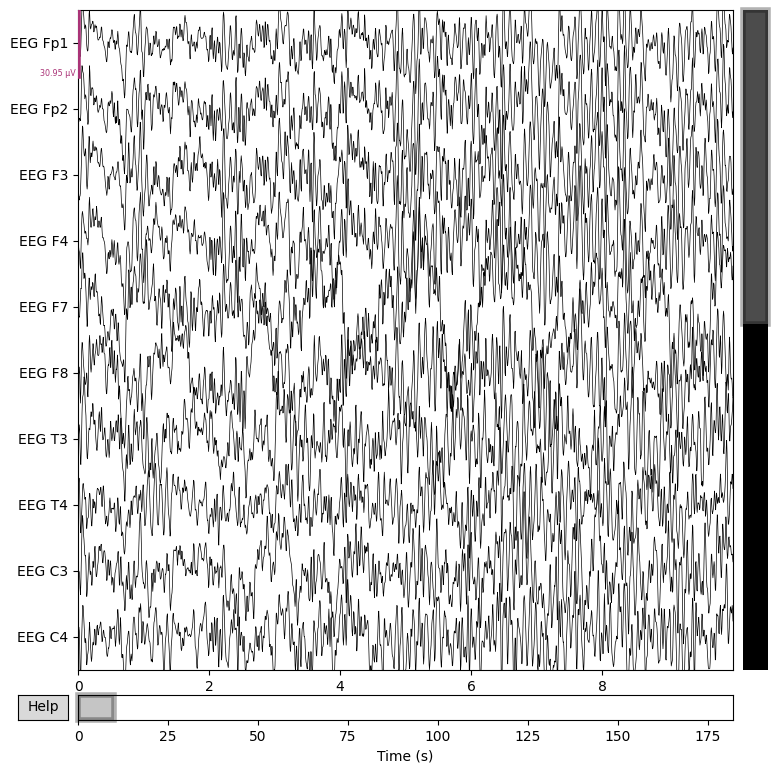

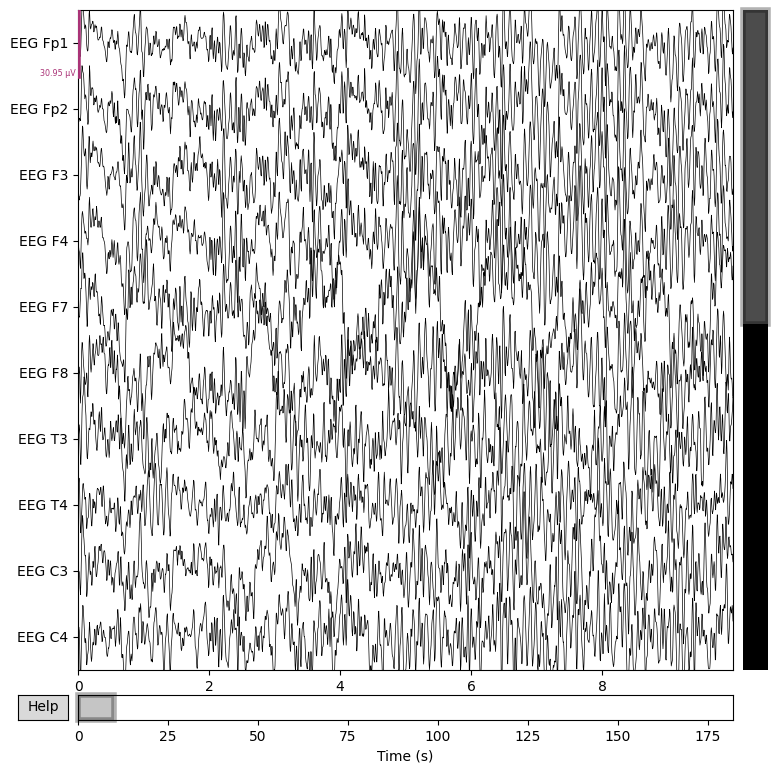

In [12]:
raw.plot(duration=10, n_channels=10, scalings="auto")